1. how to build a neural network in PyTorch
2. how to interact with a gym environment
3. how to implement the deep q learning code(stable_baselines3)
4. how to implement your own environment(design dynamic/action/reward/state update)
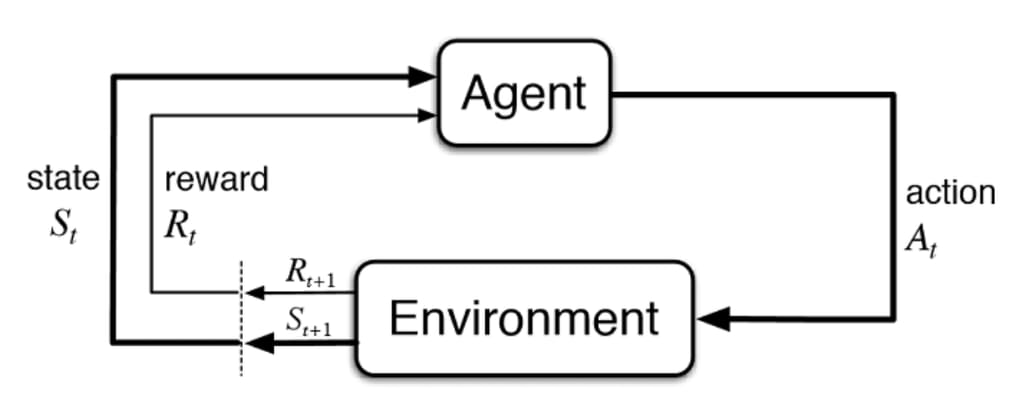

In [1]:
!pip -q install "stable-baselines3[extra]" "gymnasium[classic-control]" imageio imageio-ffmpeg
#you can use pip/conda to install those packages if you are using a different python environment


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 3.8 MB/s eta 0:00:00


In [3]:
#make sure we have the packages ready
import torch
from torch import nn #most common function
import gymnasium as gym
from stable_baselines3 import DQN #because we are using deep Q learning as an example
#following packages are mainly for visualization and demo purpose
%matplotlib inline
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"  # Headless rendering in Colab.
os.environ["SDL_AUDIODRIVER"] = "dummy"
import random
import time
from collections import deque
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from IPython.display import Video, display

SEED = 42 #so we will generate the same results
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_everything(SEED)
DEVICE = torch.device("cpu")  # we only use CPU today


print("PyTorch:", torch.__version__, "| Gymnasium:", gym.__version__)
print("Device:", DEVICE)


PyTorch: 2.11.0+cpu | Gymnasium: 1.3.0
Device: cpu


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## how to build a neural network in PyTorch
PyTorch is a deep learning framework that provides tools for constructing and training neural networks. In deep reinforcement learning, we use PyTorch to build a neural network controller that maps the observed state of the environment to an action. Its automatic differentiation and optimization tools allow the controller to learn effective actions by updating its parameters based on the collected rewards.




In [ ]:
from torch import nn #most common function
linear = nn.Linear(1, 2) #input dimension 1, output dimension 2, #y = wx+b
print(linear.weight.data) #W has shape 2*1
print(linear.bias.data)# b has shape 2
relu = nn.ReLU()  #y = max(0, x)


tensor([[-0.2191],
        [ 0.2018]])
tensor([-0.4869,  0.5873])


In [ ]:
x = torch.tensor([[0.1]])
z = linear(x) #y = wx + b
a = relu(z)
print("Input:", x.shape, "Weights:", linear.weight.shape, "Bias:", linear.bias.shape)
print("Linear output:", z.detach().numpy()) # [0.7645*x-0.2343, 0.83*x + 0.9186]
print("After ReLU:", a.detach().numpy()) #y = max(0, x)


Input: torch.Size([1, 1]) Weights: torch.Size([2, 1]) Bias: torch.Size([2])
Linear output: [[-0.5087654   0.60746175]]
After ReLU: [[0.         0.60746175]]


In [ ]:
#manually change the weights and bias
with torch.no_grad():
    linear.weight.copy_(torch.tensor([[0.5],
                                      [-0.8]]))
    linear.bias.copy_(torch.tensor([0.1, 0.3]))
x = torch.tensor([[0.1]])
z = linear(x) #y = wx + b
a = relu(z)
print("Input:", x.shape, "Weights:", linear.weight.shape, "Bias:", linear.bias.shape)
print("Linear output:", z.detach().numpy())
print("After ReLU:", a.detach().numpy())
#All the deep working training is just optimize the weight and bias.

Input: torch.Size([1, 1]) Weights: torch.Size([2, 1]) Bias: torch.Size([2])
Linear output: [[0.15 0.22]]
After ReLU: [[0.15 0.22]]


In [ ]:
#just for visualization
def draw_network(network, max_neurons=8):

    # --------------------------------------------------
    # 1. Read network structure automatically
    # --------------------------------------------------
    widths = []
    labels = []

    modules = list(network.layers)

    for i, module in enumerate(modules):

        if isinstance(module, nn.Linear):

            # First Linear layer -> also add input layer
            if len(widths) == 0:
                widths.append(module.in_features)
                labels.append("Input")

            # Check whether an activation follows this layer
            activation_name = None

            if i + 1 < len(modules):
                next_module = modules[i + 1]

                if isinstance(next_module, nn.ReLU):
                    activation_name = "ReLU"

                elif isinstance(next_module, nn.Tanh):
                    activation_name = "Tanh"

                elif isinstance(next_module, nn.Sigmoid):
                    activation_name = "Sigmoid"

            # Last linear layer
            if i == len(modules) - 1:
                label = "Output"

            elif activation_name is not None:
                label = f"Linear + {activation_name}"

            else:
                label = "Linear"

            widths.append(module.out_features)
            labels.append(label)

    # --------------------------------------------------
    # 2. Draw network
    # --------------------------------------------------
    fig, ax = plt.subplots(
        figsize=(2.5 * len(widths), 5)
    )

    positions = [
        np.linspace(-1, 1, min(width, max_neurons))
        for width in widths
    ]

    # Connections
    for layer in range(len(widths) - 1):

        for y1 in positions[layer]:

            for y2 in positions[layer + 1]:

                ax.plot(
                    [layer, layer + 1],
                    [y1, y2],
                    color="gray",
                    alpha=0.15,
                    zorder=1
                )

    # Neurons
    for layer, (width, ys) in enumerate(
        zip(widths, positions)
    ):

        ax.scatter(
            [layer] * len(ys),
            ys,
            s=220,
            zorder=2
        )

        suffix = (
            " (sample shown)"
            if width > max_neurons
            else ""
        )

        ax.text(
            layer,
            1.35,
            f"{labels[layer]}\n"
            f"{width} units{suffix}",
            ha="center",
            fontsize=10
        )

    ax.set(
        xlim=(-0.5, len(widths) - 0.5),
        ylim=(-1.3, 1.8)
    )

    ax.axis("off")

    plt.show()

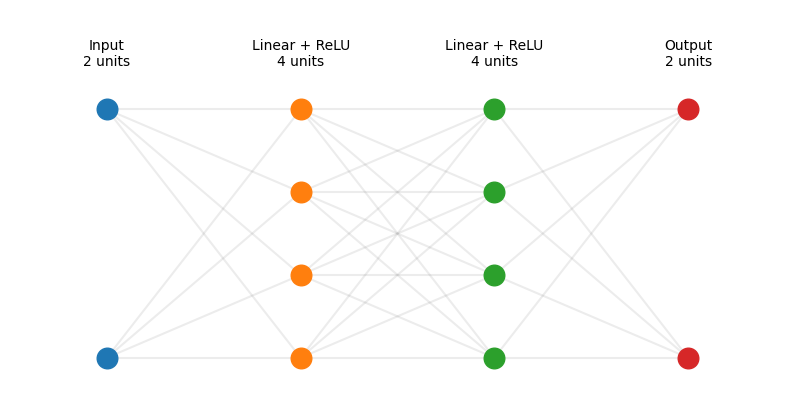

In [ ]:
#design a larger networks as a controller
#nn.Module organizes the network’s layers and parameters, and provides built-in functions for training, evaluation, and gradient computation.
class QNetwork(nn.Module): #very imporant class #we create a subclass of nn.Module.
    def __init__(self, obs_dim, n_actions, hidden=(4,)):
      #observation dimention, number of actions, and hidden layer
      #simple MLP form
        super().__init__()

        layers = [] #create a layers list
        input_dim = obs_dim

        for hidden_dim in hidden:
            layers.append(
                nn.Linear(input_dim, hidden_dim)
            )
            layers.append(
                nn.ReLU()
            )

            input_dim = hidden_dim #output dimension of the previous layer will be the input dimentsion of the next layer.

        # Output layer
        layers.append(
            nn.Linear(input_dim, n_actions)
        )

        self.layers = nn.Sequential(*layers) #Run these layers one after another, in this order

    def forward(self, states):
        return self.layers(states)

small_network = QNetwork(
    obs_dim=2,
    n_actions=2,
    hidden=[4,4]
)

draw_network(small_network)
#if you want to design a new neural network, just creat a nn.Module subclass, you can create whatever neural networks such as transformer.

### **2.how to interact with a gym environment**
CartPole-v1 is a balancing task: a pole is attached to a cart that can move horizontally. The controller pushes the cart left or right to keep the pole upright.

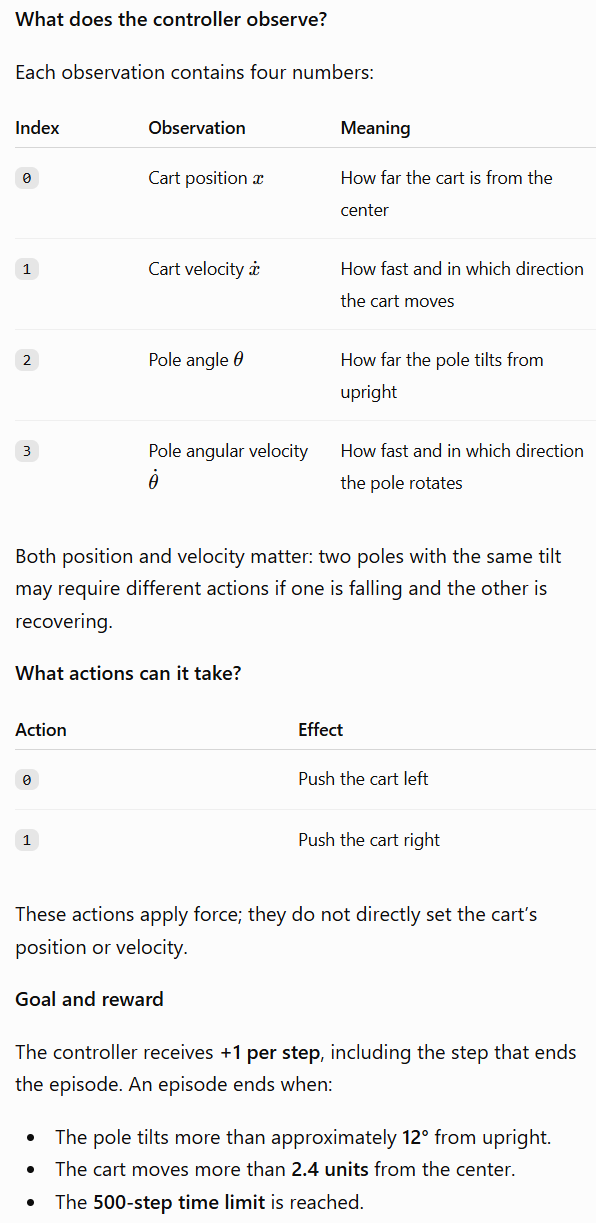



In [2]:
ENV_NAME = "CartPole-v1"
env = gym.make(ENV_NAME, render_mode="rgb_array") #start the env
state, info = env.reset(seed=SEED)  #reset the env
print("Observation:", state)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
next_state, reward, terminated, truncated, info = env.step(1) #agent take action
print("After pushing right:", next_state)
print("Reward:", reward, "terminated:", terminated, "truncated:", truncated)
OBS_DIM = env.observation_space.shape[0]
N_ACTIONS = env.action_space.n
plt.figure(figsize=(6, 4))
plt.imshow(env.render())
plt.axis("off")
plt.show()


NameError: name 'gym' is not defined

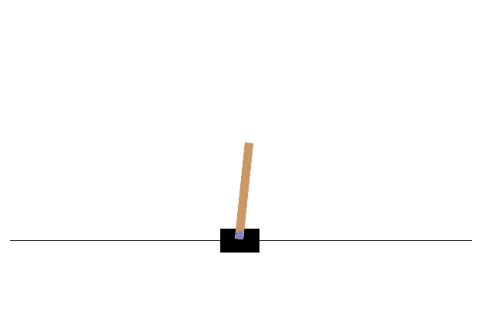

In [ ]:
#let us see what happen we push the car left for 5 times
state, info = env.reset(seed=SEED)
for i in range(5):
  next_state, reward, terminated, truncated, info = env.step(0)
plt.figure(figsize=(6, 4))
plt.imshow(env.render())
plt.axis("off")
plt.show()

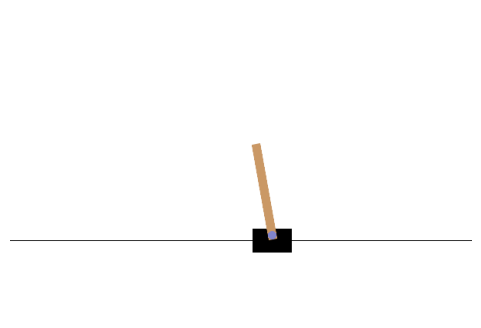

In [ ]:
#let us manually push the cart
next_state, reward, terminated, truncated, info = env.step(1)
plt.figure(figsize=(6, 4))
plt.imshow(env.render())
plt.axis("off")
plt.show()



# Now,  implement the deep q learning code

In [ ]:
#Stable-Baselines3 is a Python library that provides reliable implementations of popular reinforcement learning algorithms
#It works with Gymnasium environments and simplifies the process of training, evaluating, and saving reinforcement learning agents.
from stable_baselines3 import DQN
from stable_baselines3.dqn.policies import DQNPolicy

# Connect your existing pytorch QNetwork class to Stable-Baselines3.
class CustomDQNPolicy(DQNPolicy):
  #we transfer the neural network into DQN controller. stable_baselines3 will add more build-in function from reinforcement learning side.
    def make_q_net(self):
        # SB3 wrapper handles observation processing and action selection.
        network = super().make_q_net()

        # Replace its internal neural network with predefined QNetwork. we can use any neural networks here.
        network.q_net = QNetwork(
            obs_dim=network.features_dim,
            n_actions=int(self.action_space.n),
            hidden=tuple(self.net_arch),
        )

        return network.to(self.device)

env = gym.make(ENV_NAME) #make env
model = DQN(
    policy=CustomDQNPolicy,
    env=env,

    # Your QNetwork: 6 inputs -> 64 -> 64 -> 3 Q-values
    policy_kwargs=dict(net_arch=[64, 64]), #design neural networks

    learning_rate=6e-4, #Controls how quickly the network weights are updated
    buffer_size=100_000, # Stores up to 100,000 past experiences.
    learning_starts=1_000, #Delays learning until 1,000 experiences are collected.
    batch_size=64, # Uses 64 randomly sampled experiences per update.
    gamma=0.99, # Determines how much future rewards are valued.

    train_freq=4, # Trains the network every 4 environment steps.
    gradient_steps=1, # Performs one gradient update after each training interval.
    target_update_interval=500, # Updates the target network every 500 environment steps. Target netowrk is is a copy of the main Q-network used to calculate stable target Q-values, making DQN training more stable.

    exploration_initial_eps=1.0, # Starts with a 100% probability of taking random actions.
    exploration_final_eps=0.05, # Ends with a 5% probability of taking random actions.
    exploration_fraction=0.3, # Decays exploration over the first 30% of training.

    verbose=1, #if display training progress
    seed=42, #so everyone will get same result
    device="cpu",
)
#try to modify parameters to achieve a higher reward
model.learn(total_timesteps=100_00) #10,000 training steps. more total_timesteps = more training time.

model.save("dqn_acrobot") #save the model
env.close()

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 23       |
|    ep_rew_mean      | 23       |
|    exploration_rate | 0.971    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 4359     |
|    time_elapsed     | 0        |
|    total_timesteps  | 92       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 24.9     |
|    ep_rew_mean      | 24.9     |
|    exploration_rate | 0.937    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 4191     |
|    time_elapsed     | 0        |
|    total_timesteps  | 199      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 26.8     |
|    ep_rew_mean      | 26.8   

In [ ]:
from stable_baselines3.common.evaluation import evaluate_policy
from IPython.display import Video, display
import imageio.v2 as imageio
from stable_baselines3.common.monitor import Monitor
eval_env = Monitor(gym.make(ENV_NAME))

mean_reward, std_reward = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=20,
    deterministic=True
)

print(f"Mean reward: {mean_reward:.2f} +/- {std_reward:.2f}")
#for visualization
eval_env.close()
render_env = gym.make(
    ENV_NAME,
    render_mode="rgb_array"
)

observation, info = render_env.reset(seed=123)

frames = []
rewards = []
actions = []

terminated = False
truncated = False

while not (terminated or truncated):
    frame = render_env.render() #key line
    frames.append(frame)

    action, _ = model.predict(
        observation,
        deterministic=True
    )

    actions.append(int(action))

    observation, reward, terminated, truncated, info = render_env.step(action)
    rewards.append(reward)

render_env.close()

print(f"Episode length: {len(rewards)}")
print(f"Total reward: {sum(rewards):.2f}")
print(f"Actions taken: {actions[:20]}")
import imageio.v2 as imageio

video_path = "ppo_cartpole_demo.mp4"

with imageio.get_writer(
    video_path,
    fps=30,
    codec="libx264"
) as writer:
    for frame in frames:
        writer.append_data(frame)

display(Video(video_path, embed=True))

Mean reward: 190.50 +/- 34.72


Episode length: 180
Total reward: 180.00
Actions taken: [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]


In [ ]:
# Colab: run once
%pip install -q "gym==0.23.1" "pymunk<7" pygame shimmy stable-baselines3
%pip install -q --no-deps "drone-2d-custom-gym-env==1.3.3"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.3 MB/s eta 0:00:00


## 4. how to implement your own environment
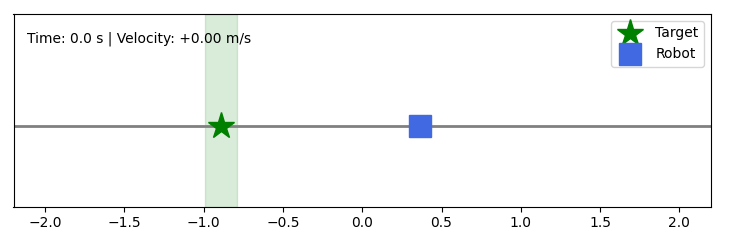


## 1D Robot: Reach the Target and Stop

A robot moves along a horizontal line. Its goal is to reach a target and slow down enough to stop near it.

The robot has momentum, so it must learn both **when to accelerate** and **when to brake**.

### Observation and actions

The observation contains three values:

$$
o = [x,\ v,\ x_{\text{target}}]
$$

Here, $x$ is the robot's position, $v$ is its velocity, and $x_{\text{target}}$ is the target position.

| Action | Acceleration | Meaning |
|---|---|---|
| 0 | $-1\ \mathrm{m/s^2}$ | Accelerate left |
| 1 | $0\ \mathrm{m/s^2}$ | Coast |
| 2 | $+1\ \mathrm{m/s^2}$ | Accelerate right |

**Coasting does not stop the robot:** it continues moving at its current velocity. Braking requires acceleration opposite to its motion.

### How `step(action)` works

Each step represents $\Delta t = 0.1$ seconds.

First, update velocity and limit it to $[-1.5, 1.5]\ \mathrm{m/s}$:

$$
v \leftarrow \operatorname{clip}(v + a\Delta t,\ -1.5,\ 1.5)
$$

Then update position using the new velocity:

$$
x \leftarrow x + v\Delta t
$$

The environment calculates a reward and checks whether the episode has ended.

### Reward and episode ending

The reward encourages progress toward the target and penalizes time, distance, and speed.

- **Success:** distance to target is less than $0.1$ m and speed is less than $0.15$ m/s. Receive a bonus of $+10$.
- **Failure:** move outside $[-2, 2]$ m. Receive a penalty of $-10$.
- **Time limit:** truncate the episode after 150 steps.

### How DQN controls the robot

The neural network receives the three observation values and predicts one Q-value for each action:

$$
[x,\ v,\ x_{\text{target}}]
\longrightarrow
[Q(\text{left}),\ Q(\text{coast}),\ Q(\text{right})]
$$

Each Q-value estimates the discounted future reward from choosing that action and following the learned policy afterward.

During training, the agent sometimes takes random actions to explore. During evaluation, it selects the action with the highest predicted Q-value.

In [ ]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces


class LineRobotEnv(gym.Env):
    """Move a robot along a line and stop near a target."""

    metadata = {"render_modes": []}

    def __init__(self): #parameters we need for the robot
        super().__init__()

        self.dt = 0.1
        self.max_acceleration = 1.0
        self.max_speed = 1.5
        self.position_limit = 2.0
        self.max_steps = 150

        # 0 = accelerate left, 1 = coast, 2 = accelerate right.
        self.action_space = spaces.Discrete(3)
        #[position, velocity, target]
        # Position is unbounded here to include terminal overshoot.
        self.observation_space = spaces.Box(
            low=np.array([-np.inf, -self.max_speed, -1.0],
                         dtype=np.float32),
            high=np.array([np.inf, self.max_speed, 1.0],
                          dtype=np.float32),
            dtype=np.float32,
        )

    def _get_obs(self):
        return np.array(
            [self.position, self.velocity, self.target],
            dtype=np.float32,
        )

    def _get_info(self):
        #check if we are success
        return {
            "distance": float(abs(self.position - self.target)),
            "is_success": bool(
                abs(self.position - self.target) < 0.1
                and abs(self.velocity) < 0.15
            ),
        }

    def reset(self, *, seed=None, options=None):
      #define observation and initial state
        super().reset(seed=seed)
        self.position = float(self.np_random.uniform(-1.0, 1.0))
        self.velocity = 0.0
        self.target = float(self.np_random.uniform(-1.0, 1.0))
        # Place the target away from the initial position.
        while abs(self.target - self.position) < 0.5:
            self.target = float(self.np_random.uniform(-1.0, 1.0))

        self.steps = 0 #count history
        self.episode_done = False #let us know we need to reset

        return self._get_obs(), self._get_info()

    def step(self, action): #what will happen after taking actions
        #check if we need to reset
        if self.episode_done:
            raise RuntimeError("Episode finished. Call reset().")
        #check if action is valid
        action = int(action)
        if not self.action_space.contains(action):
            raise ValueError("Action must be 0, 1, or 2.")

        previous_distance = abs(self.position - self.target)

        # Convert the discrete action into acceleration.
        acceleration = (action - 1) * self.max_acceleration #0 means -max_acceleration, 1 means 0, 1 means +max_acceleration

        # Update velocity first, #v = v + acceleration, bound by speed limits
        self.velocity = float(np.clip(
            self.velocity + acceleration * self.dt,
            -self.max_speed,
            self.max_speed,
        ))
        #then position. position = position + velocity*dt
        self.position += self.velocity * self.dt
        self.steps += 1

        distance = abs(self.position - self.target) #get the distance
        info = self._get_info() #check if we are success
        success = info["is_success"]
        out_of_bounds = abs(self.position) > self.position_limit #check if we violated the position bound

        # Reward progress; penalize time, distance, and speed.
        reward = (
            5.0 * (previous_distance - distance)
            - 0.05
            - 0.1 * distance
            - 0.05 * self.velocity**2
        )

        if success:
            reward += 10.0
        elif out_of_bounds:
            reward -= 10.0

        terminated = bool(success or out_of_bounds)
        truncated = bool(
            self.steps >= self.max_steps and not terminated
        )
        self.episode_done = terminated or truncated #env need to be reset either terminated/truncated
        info["out_of_bounds"] = bool(out_of_bounds)

        return (
            self._get_obs(),
            float(reward),
            terminated,
            truncated,
            info,
        )

In [ ]:
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.env_checker import check_env

check_env(LineRobotEnv())

train_env = Monitor(LineRobotEnv())

model = DQN(
    policy="MlpPolicy",
    env=train_env,
    policy_kwargs=dict(net_arch=[64, 64]),

    learning_rate=1e-3,         # Optimizer step size.
    buffer_size=50_000,        # Maximum stored transitions.
    learning_starts=1_000,     # Collect experience before training.
    batch_size=64,            # Transitions per gradient update.
    gamma=0.99,                # Discount factor.

    train_freq=4,             # Train every four environment steps.
    gradient_steps=1,         # One update per training event.
    target_update_interval=500,

    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    exploration_fraction=0.4, # Reduce exploration over first 40%.

    verbose=0,
    seed=42,
    device="cpu",
)

model.learn(total_timesteps=50_000)
model.save("dqn_line_robot")
train_env.close()

print("Training finished.")

Training finished.


In [ ]:
eval_env = LineRobotEnv()
returns = []
successes = []

for episode in range(50):
    obs, info = eval_env.reset(seed=1000 + episode)
    episode_return = 0.0

    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(
            int(action.item())
        )
        episode_return += reward

        if terminated or truncated:
            break

    returns.append(episode_return)
    successes.append(info["is_success"])

eval_env.close()

print(f"Mean return: {np.mean(returns):.2f}")
print(f"Success rate: {100 * np.mean(successes):.1f}%")

Mean return: 6.95
Success rate: 72.0%


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

env = LineRobotEnv()
obs, _ = env.reset(seed=123)

positions = [env.position]
velocities = [env.velocity]
target = env.target

for _ in range(env.max_steps):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(
        int(action.item())
    )

    positions.append(env.position)
    velocities.append(env.velocity)

    if terminated or truncated:
        break

fig, ax = plt.subplots(figsize=(9, 2.5))
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-0.5, 0.7)
ax.set_yticks([])
ax.set_xlabel("Position")
ax.axhline(0, color="gray", linewidth=2)
ax.axvspan(target - 0.1, target + 0.1, color="green", alpha=0.15)
ax.plot(target, 0, "*", color="green", markersize=20, label="Target")

robot, = ax.plot([], [], "s", color="royalblue",
                 markersize=16, label="Robot")
status = ax.text(0.02, 0.85, "", transform=ax.transAxes)
ax.legend(loc="upper right")


def update(frame):
    robot.set_data([positions[frame]], [0])
    status.set_text(
        f"Time: {frame * env.dt:.1f} s | "
        f"Velocity: {velocities[frame]:+.2f} m/s"
    )
    return robot, status


animation = FuncAnimation(
    fig,
    update,
    frames=len(positions),
    interval=env.dt * 1000,
    blit=True,
)

plt.close(fig)
display(HTML(animation.to_jshtml()))
print("Reached target and stopped:", info["is_success"])
env.close()

Reached target and stopped: True


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
